# Day38_PCA_TSNE
29-apr-25

# 38.1 PCA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
data=pd.read_csv('Universities.csv')
data.head(3)

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72


In [52]:
data=data.set_index('Univ')
data.head(3)

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,1310,89,22,13,22704,94
CalTech,1415,100,25,6,63575,81
CMU,1260,62,59,9,25026,72


- Standardise the data - mandatory step for PCA

In [55]:
from sklearn.preprocessing import StandardScaler

In [57]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data)
#scaled_data = scaler.fit_transform(data)
scaled_data

array([[ 0.41028362,  0.6575195 , -0.88986682,  0.07026045, -0.33141256,
         0.82030265],
       [ 1.39925928,  1.23521235, -0.73465749, -1.68625071,  2.56038138,
        -0.64452351],
       [-0.06065717, -0.76045386,  1.02438157, -0.93346022, -0.16712136,
        -1.65863393],
       [ 0.41028362, -0.02520842, -0.78639393, -0.18066972,  0.29164871,
         0.14422904],
       [ 0.12771914,  0.34241431, -0.32076595,  0.07026045, -0.39084607,
         0.36958691],
       [ 0.69284809,  0.6575195 , -0.83813038, -0.68253005,  0.33778044,
         0.93298158],
       [ 0.4573777 ,  0.71003703, -0.47597528, -0.18066972,  0.29695528,
         0.93298158],
       [-0.10775125, -0.13024348, -0.78639393, -0.18066972, -0.51381683,
         0.59494478],
       [ 1.25797704,  0.76255456, -1.30375836, -0.43159988,  0.85874344,
         1.15833946],
       [ 0.36318954, -0.07772595,  0.24833493, -1.43532055,  2.21481798,
         0.0315501 ],
       [ 1.06960072,  0.92010716, -0.47597528, -0.

- Reduce the dimentionality by usign PCA

In [60]:
from sklearn.decomposition import PCA

In [86]:
model=PCA(n_components=6) # n_components=6 - no of features can be passed
# n_components=0.95 - means it will return only those columns whose sum of weightage is 95%.
decomposed_data=model.fit_transform(scaled_data)
decomposed_data

array([[ 1.00987445e+00, -1.06430962e+00,  8.10663051e-02,
        -5.69506350e-02, -1.28754245e-01, -3.46496377e-02],
       [ 2.82223781e+00,  2.25904458e+00,  8.36828830e-01,
        -1.43844644e-01, -1.25961913e-01, -1.80703168e-01],
       [-1.11246577e+00,  1.63120889e+00, -2.66786839e-01,
        -1.07507502e+00, -1.91814148e-01,  3.45679459e-01],
       [ 7.41741217e-01, -4.21874699e-02,  6.05008649e-02,
         1.57208116e-01, -5.77611392e-01,  1.09163092e-01],
       [ 3.11912064e-01, -6.35243572e-01,  1.02405189e-02,
        -1.71363672e-01,  1.27261287e-02, -1.69212696e-02],
       [ 1.69669089e+00, -3.44363283e-01, -2.53407507e-01,
        -1.25643278e-02, -5.26606002e-02, -2.71661600e-02],
       [ 1.24682093e+00, -4.90983662e-01, -3.20938196e-02,
         2.05643780e-01,  2.93505340e-01, -7.80119838e-02],
       [ 3.38749784e-01, -7.85168589e-01, -4.93584829e-01,
        -3.98563085e-02, -5.44978619e-01, -1.55371653e-01],
       [ 2.37415013e+00, -3.86538883e-01,  1.160

- Check the variance(how much percent of information each column carries) of each column and decide how many columns are enough for model.

In [89]:
ratio=model.explained_variance_ratio_
ratio

array([0.76868084, 0.13113602, 0.04776031, 0.02729668, 0.0207177 ,
       0.00440844])

In [91]:
# Or also we can see the cumulative sum
var=np.cumsum(ratio)
var

array([0.76868084, 0.89981687, 0.94757718, 0.97487386, 0.99559156,
       1.        ])

In [ ]:
# means first theree features carriees 0.94757718% of information
# means first four features carriees 0.97487386% of information

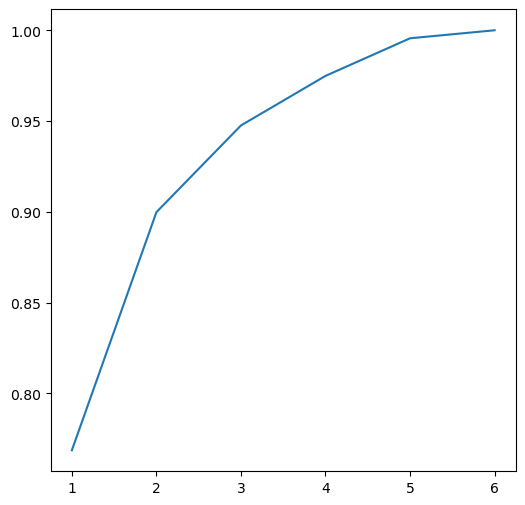

In [95]:
# line chart
plt.figure(figsize=(6,6))
plt.plot(range(1,7),var)
plt.show()

In [ ]:
# Brachart

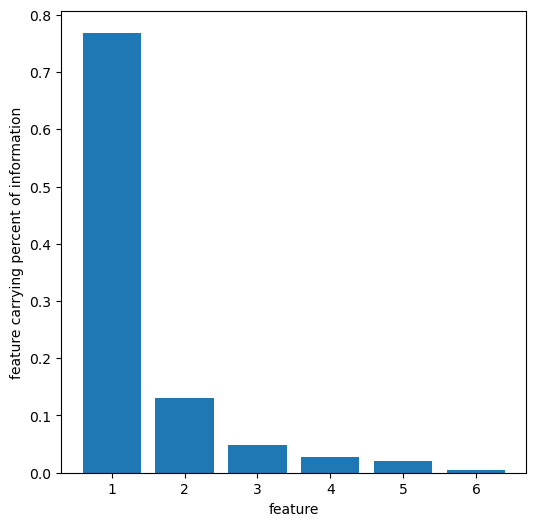

In [99]:
plt.figure(figsize=(6,6))
plt.bar(range(1,7),ratio)
plt.xlabel('feature')
plt.ylabel('feature carrying percent of information')
plt.show()

In [103]:
# If we are satisfied with columns which are carrying 35% information then create a new dataset with only foou columns and use that dataset while building the model
new_data=data.iloc[:,0:4]
new_data.head(3)

,SAT,Top10,Accept,SFRatio
Univ,,,,
Brown,1310,89,22,13
CalTech,1415,100,25,6
CMU,1260,62,59,9


# TSNE 

In [107]:
from sklearn.manifold import TSNE

In [111]:
iris = pd.read_csv('iris.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [113]:
features = iris.iloc[:,:4]
features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [115]:
tsne = TSNE(n_components=2)
tdata = tsne.fit_transform(features)
tdata

array([[-23.875437  ,  -1.4305894 ],
       [-21.332832  ,  -2.5229647 ],
       [-21.183956  ,  -1.3164853 ],
       [-20.842545  ,  -1.61192   ],
       [-23.845785  ,  -0.9457335 ],
       [-25.833662  ,  -0.9249592 ],
       [-21.434713  ,  -0.7261155 ],
       [-23.135448  ,  -1.5997264 ],
       [-20.077644  ,  -1.7236085 ],
       [-21.728899  ,  -2.2258704 ],
       [-25.438894  ,  -1.6185867 ],
       [-22.392347  ,  -1.1686792 ],
       [-20.983025  ,  -2.2591443 ],
       [-19.860811  ,  -1.1332073 ],
       [-26.776562  ,  -1.5117849 ],
       [-26.88732   ,  -0.9376887 ],
       [-26.012383  ,  -1.2746142 ],
       [-23.93844   ,  -1.5569798 ],
       [-26.26575   ,  -1.8069136 ],
       [-24.88065   ,  -0.82918686],
       [-24.896988  ,  -2.4844184 ],
       [-24.62376   ,  -1.0674903 ],
       [-21.465752  ,   0.10849005],
       [-23.518333  ,  -2.8430624 ],
       [-22.436312  ,  -0.6163109 ],
       [-21.753988  ,  -2.7942991 ],
       [-23.376272  ,  -2.279838  ],
 

In [117]:
tdf = pd.DataFrame(tdata, columns=['c1','c2'])
tdf['species'] = iris['species']
tdf.head()

,c1,c2,species
0,-23.875437,-1.430589,setosa
1,-21.332832,-2.522965,setosa
2,-21.183956,-1.316485,setosa
3,-20.842545,-1.611920,setosa
4,-23.845785,-0.945733,setosa


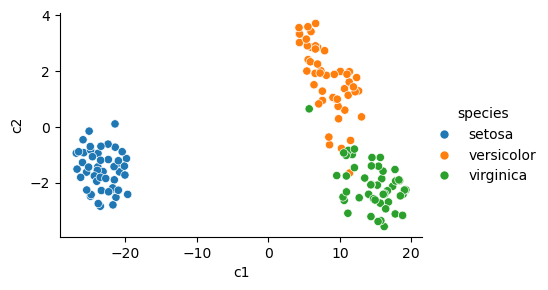

In [119]:
sns.relplot(tdf, x='c1', y='c2', kind = 'scatter', hue='species', height=3, aspect=1.5)
plt.show()